# ASOS Data Processing - PRCP Comparison

Process and compare **precipitation (PRCP)** data from ASOS 5-minute and Snow daily sources.

## Key Principle: PRCP Should Match

**The primary comparison is PRCP (precipitation):**
- **ASOS 5-minute**: Sum all 5-minute precipitation values to get daily total
- **Snow daily PRCP**: Daily precipitation value
- **Expected**: Daily PRCP totals should match (+- measurement differences) since they measure the same thing

**Snow (SNOW column)** is separate and will be analyzed later.

**Features:**
- Load ASOS 5-minute data and aggregate precipitation to daily totals
- Load Snow daily data (contains PRCP column)
- **Compare PRCP**: ASOS daily sum (from 5-min) vs Snow daily PRCP
- Validate data consistency between sources
- Plot accumulated PRCP for visual comparison

**Data Sources:**
- **ASOS**: `../../data/noaa_asos/*.csv` (5-minute resolution)
  - Contains: `precip_mm` - precipitation in 5-minute intervals
- **Snow**: `../../data/noaa_asos/snow/snow_data_processed.csv` (daily)
  - Contains: `PRCP` - daily precipitation (should match ASOS daily sum)
  - Also contains: `SNOW`, `SNWD` (analyzed separately later)


## 1. Setup & Imports


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Import functions from the functions file
from asos_data_functions import (
    STATION_CODES,
    load_asos_5min_data,
    load_snow_daily_data,
    aggregate_asos_5min_to_daily_prcp,
    process_prcp_data_comparison,
    compare_prcp_daily_vs_5min,
    plot_accumulated_prcp
)

print("✓ Imports complete")


✓ Imports complete


## 2. Configuration


In [2]:
# Data paths
DATA_DIR = Path('../../data/noaa_asos')
SNOW_DATA_DIR = DATA_DIR / 'snow'

print(f"Target stations: {list(STATION_CODES.values())}")
print(f"ASOS data directory: {DATA_DIR.absolute()}")
print(f"Snow data directory: {SNOW_DATA_DIR.absolute()}")


Target stations: ['Central Park', 'JFK Airport', 'LaGuardia Airport']
ASOS data directory: /Users/drorjac/OpenMesh_pynncml/src/analysis/asos_analysis/../../data/noaa_asos
Snow data directory: /Users/drorjac/OpenMesh_pynncml/src/analysis/asos_analysis/../../data/noaa_asos/snow


## 3. Load Data

**Note**: Functions are imported from `asos_data_functions.py`


In [3]:
# Load ASOS 5-minute data for all stations
print("="*60)
print("LOADING ASOS 5-MINUTE DATA")
print("="*60)

asos_5min_data = {}
for station_id in STATION_CODES.keys():
    df_5min = load_asos_5min_data(station_id, DATA_DIR)
    if df_5min is not None:
        asos_5min_data[station_id] = df_5min

print(f"\n✓ Loaded data for {len(asos_5min_data)} stations")


LOADING ASOS 5-MINUTE DATA

Loading KNYC:
  Found 3 file(s)
    KNYC_20231001_20250512_5min.csv: 18,004 rows
    KNYC_20231029_20251130_5min.csv: 22,954 rows
    KNYC_20250512_20251201_5min.csv: 5,827 rows
  ✓ Combined: 46,785 total rows
  Date range: 2023-10-01 00:51:00 to 2025-11-30 23:51:00

Loading KJFK:
  Found 3 file(s)
    KJFK_20231001_20250512_5min.csv: 177,335 rows
    KJFK_20231029_20251130_5min.csv: 231,082 rows
    KJFK_20250512_20251201_5min.csv: 62,848 rows
  ✓ Combined: 471,265 total rows
  Date range: 2023-10-01 00:00:00 to 2025-11-30 23:55:00

Loading KLGA:
  Found 3 file(s)
    KLGA_20231001_20250512_5min.csv: 181,949 rows
    KLGA_20231029_20251130_5min.csv: 234,996 rows
    KLGA_20250512_20251201_5min.csv: 62,156 rows
  ✓ Combined: 479,101 total rows
  Date range: 2023-10-01 00:00:00 to 2025-11-30 23:55:00

✓ Loaded data for 3 stations


### 3.2. Load Snow Daily Data (Contains PRCP/Precipitation)


In [4]:
# Load snow daily data
print("="*60)
print("LOADING SNOW DAILY DATA")
print("="*60)

df_snow_daily = load_snow_daily_data(SNOW_DATA_DIR)

if df_snow_daily is not None:
    print(f"\nSnow data columns: {list(df_snow_daily.columns)}")
    
    # Highlight PRCP column for precipitation comparison
    if 'PRCP' in df_snow_daily.columns:
        print(f"\n⚠ IMPORTANT: Snow data contains PRCP (precipitation) column")
        print(f"  This will be compared with ASOS aggregated precipitation for validation")


LOADING SNOW DAILY DATA

✓ Loaded snow data: 3,126 rows
  Date range: 2023-01-01 to 2025-11-27
  Stations: KJFK, KLGA, KNYC
  ✓ Contains PRCP (precipitation): 1,039 days with rain
    Total PRCP: 9985.25 mm across all stations

Snow data columns: ['DATE', 'station_code', 'PRCP', 'SNOW', 'SNWD', 'TMAX', 'TMIN', 'TAVG', 'AWND', 'WSF2', 'WSF5', 'WDF2', 'WDF5', 'STATION', 'NAME', 'is_rain_day', 'PRCP_cumulative', 'rain_event']

⚠ IMPORTANT: Snow data contains PRCP (precipitation) column
  This will be compared with ASOS aggregated precipitation for validation


## 4. Process PRCP Data Comparison

**Compare PRCP (precipitation) between ASOS and Snow data sources.**

**Logic:**
- ASOS 5-minute `precip_mm` values are **summed** to get daily totals
- Snow daily `PRCP` values are **direct daily measurements**
- **They should match** (+- measurement differences) since both measure precipitation

This function:
- Aggregates ASOS 5-minute precipitation to daily totals
- Compares with Snow daily PRCP values
- Creates summary statistics showing agreement between sources


In [5]:
# Process PRCP comparison data
# Optional: Set date range (leave as None for all data)
START_DATE = None  # e.g., '2024-01-01'
END_DATE = None    # e.g., '2024-03-31'

print("="*60)
print("PROCESSING PRCP DATA COMPARISON")
print("="*60)
print(f"Date range: {START_DATE or 'All data'} to {END_DATE or 'All data'}")

comparison_dict = process_prcp_data_comparison(
    asos_5min_data,
    df_snow_daily,
    start_date=START_DATE,
    end_date=END_DATE
)

if comparison_dict:
    print("\n✓ Processing complete!")
    print(f"\nDaily comparison shape: {comparison_dict['daily_comparison'].shape}")
    print(f"Summary shape: {comparison_dict['summary'].shape}")
    print("\nSummary Statistics:")
    print(comparison_dict['summary'].to_string(index=False))


PROCESSING PRCP DATA COMPARISON
Date range: All data to All data

✓ Processing complete!

Daily comparison shape: (3135, 6)
Summary shape: (3, 11)

Summary Statistics:
station_code  Total_Days_ASOS  Total_Days_Snow  Overlapping_Days  ASOS_Total_Prcp  Snow_Total_Prcp  ASOS_Mean_Daily  Snow_Mean_Daily  Mean_Difference       RMSE  Correlation
        KJFK              792             1003               760       32912.7612         2983.230        41.556517         2.974307        38.943982 120.357857     0.794679
        KLGA              792             1062               789       35848.4678         3511.550        45.263217         3.306544        42.445525 126.225319     0.791759
        KNYC              792             1032               789       12780.4672         3490.468        16.136954         3.382236        13.103889  45.142972     0.776108


## 5. Compare PRCP: ASOS Daily Sum vs Snow Daily PRCP

**Comparison Logic:**
- **ASOS PRCP**: Daily total = sum of all 5-minute `precip_mm` values for that day
- **Snow PRCP**: Daily value directly from `PRCP` column
- **Expected Result**: Values should be similar (+- measurement differences) since both measure precipitation

This shows statistics for days where both sources have PRCP data.


In [6]:
# Get comparison data for days with both ASOS and Snow PRCP
if comparison_dict:
    df_prcp_comparison = compare_prcp_daily_vs_5min(comparison_dict)
    
    print(f"\n✓ Found {len(df_prcp_comparison)} days with both ASOS and Snow PRCP data")
    print("\nFirst 10 comparison days:")
    print(df_prcp_comparison.head(10)[['DATE', 'station_code', 'ASOS_PRCP', 'Snow_PRCP', 'Difference']].to_string(index=False))
    
    print("\nStatistics by station:")
    for station_id in df_prcp_comparison['station_code'].unique():
        df_station = df_prcp_comparison[df_prcp_comparison['station_code'] == station_id]
        print(f"\n{station_id}:")
        print(f"  Days: {len(df_station)}")
        print(f"  ASOS total: {df_station['ASOS_PRCP'].sum():.2f} mm")
        print(f"  Snow total: {df_station['Snow_PRCP'].sum():.2f} mm")
        print(f"  Mean difference: {df_station['Difference'].mean():.2f} mm")
        print(f"  RMSE: {np.sqrt((df_station['Difference']**2).mean()):.2f} mm")
        print(f"  Correlation: {df_station['ASOS_PRCP'].corr(df_station['Snow_PRCP']):.3f}")
else:
    print("⚠ Comparison data not available")



✓ Found 2338 days with both ASOS and Snow PRCP data

First 10 comparison days:
      DATE station_code  ASOS_PRCP  Snow_PRCP  Difference
2023-10-01         KJFK     0.0000      0.000      0.0000
2023-10-02         KJFK     0.0000      0.000      0.0000
2023-10-03         KJFK     0.0000      0.000      0.0000
2023-10-04         KJFK     0.0000      0.000      0.0000
2023-10-05         KJFK     0.0000      0.000      0.0000
2023-10-06         KJFK     0.0508      0.000      0.0508
2023-10-07         KJFK   420.0652     47.752    372.3132
2023-10-08         KJFK     0.0000      0.000      0.0000
2023-10-09         KJFK     0.0000      0.000      0.0000
2023-10-10         KJFK     0.0508      0.000      0.0508

Statistics by station:

KJFK:
  Days: 760
  ASOS total: 31680.73 mm
  Snow total: 2083.31 mm
  Mean difference: 38.94 mm
  RMSE: 120.36 mm
  Correlation: 0.795

KLGA:
  Days: 789
  ASOS total: 35832.67 mm
  Snow total: 2343.15 mm
  Mean difference: 42.45 mm
  RMSE: 126.23 mm
  Cor

## 6. Plot Accumulated PRCP

**Visual Comparison:** Plot cumulative precipitation from both sources.

The lines should track closely since:
- ASOS accumulated = sum of daily totals (from 5-minute data)
- Snow accumulated = sum of daily PRCP values
- Both measure the same thing (precipitation), so accumulated totals should match

**Note:** Snow (SNOW column) is separate and not included here - only PRCP comparison.


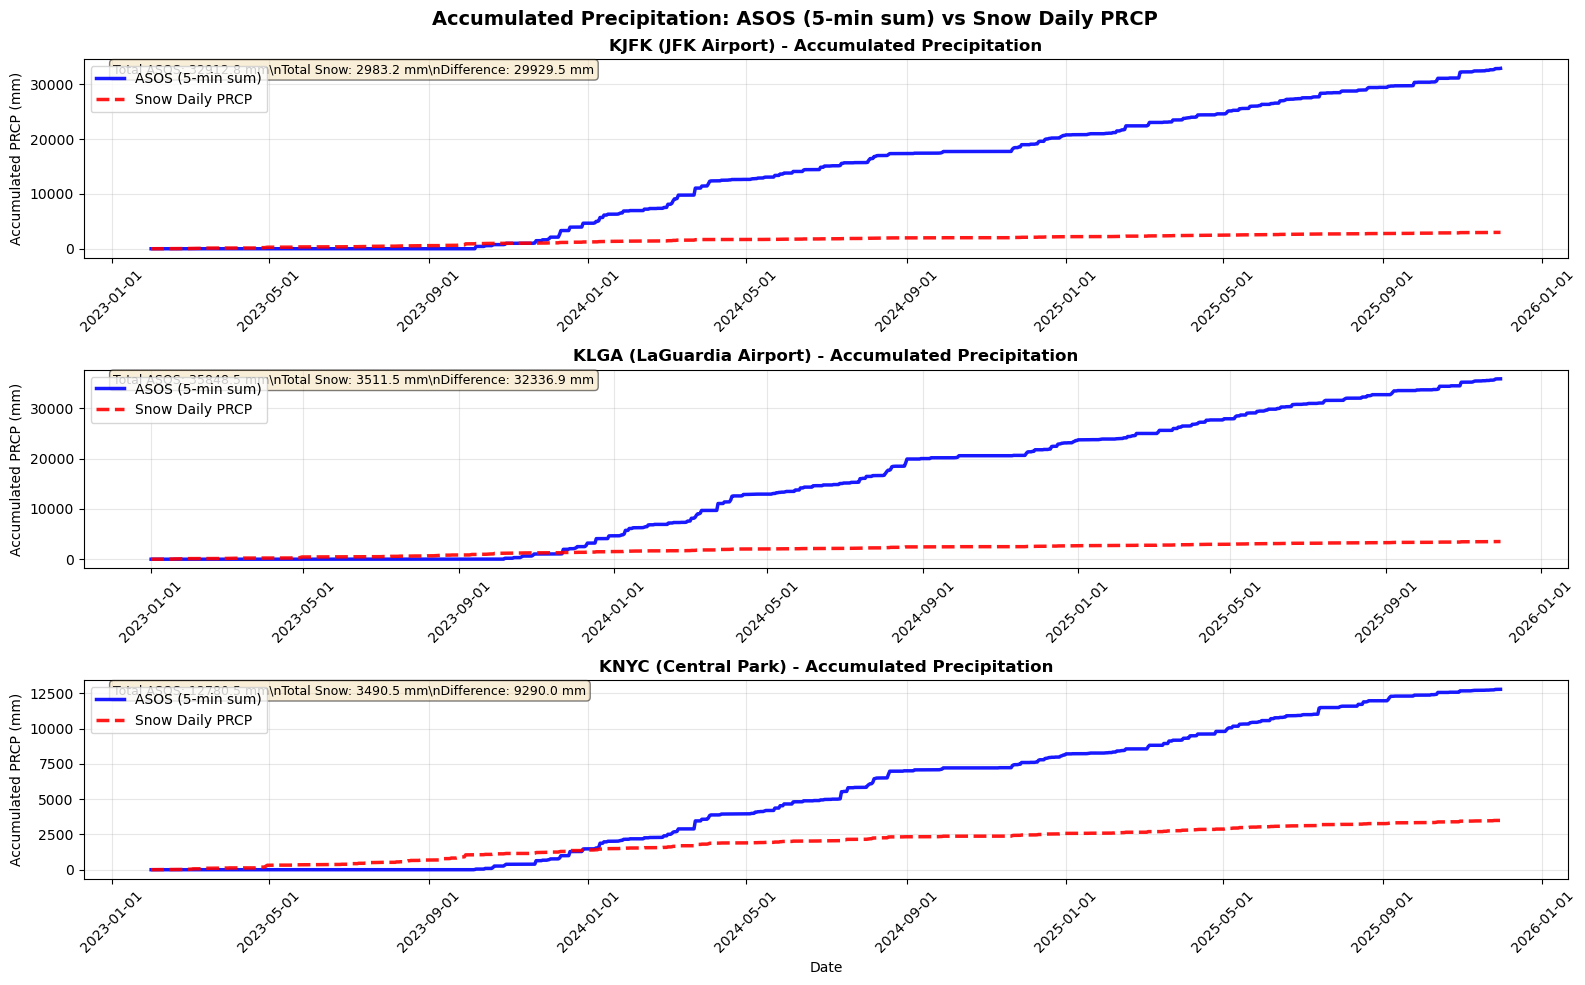

✓ Accumulated PRCP plot created


In [11]:
# Plot accumulated PRCP for all stations
if comparison_dict:
    # Optional: Set date range for plotting (leave as None for all data)
    PLOT_START_DATE = None  # e.g., '2024-01-01'
    PLOT_END_DATE = None    # e.g., '2024-03-31'
    
    fig, axes = plot_accumulated_prcp(
        comparison_dict,
        start_date=PLOT_START_DATE,
        end_date=PLOT_END_DATE,
        stations=None,  # None = all stations, or ['KJFK', 'KLGA']
        figsize=(16, 10)
    )
    
    if fig is not None:
        plt.show()
        print("✓ Accumulated PRCP plot created")
    else:
        print("⚠ Could not create plot")
else:
    print("⚠ Comparison data not available")


### 7.1. Analyze Precipitation Data Resolution/Quantization

Check the resolution (smallest step) in the 5-minute precipitation data


In [12]:
# Analyze precipitation resolution/quantization in ASOS 5-minute data
print("="*60)
print("PRECIPITATION RESOLUTION ANALYSIS")
print("="*60)

for station_id, df_5min in asos_5min_data.items():
    if 'precip_mm' in df_5min.columns:
        precip = df_5min['precip_mm'].dropna()
        precip_nonzero = precip[precip > 0]
        
        if len(precip_nonzero) > 0:
            print(f"\n{station_id}:")
            print(f"  Total records: {len(precip):,}")
            print(f"  Non-zero precipitation: {len(precip_nonzero):,}")
            print(f"  Min non-zero value: {precip_nonzero.min():.6f} mm")
            print(f"  Max value: {precip_nonzero.max():.6f} mm")
            
            # Get unique values and find smallest step
            unique_vals = sorted(precip_nonzero.unique())
            print(f"  Unique non-zero values: {len(unique_vals)}")
            
            if len(unique_vals) > 1:
                # Calculate differences between consecutive sorted values
                diffs = np.diff(unique_vals)
                min_diff = diffs[diffs > 0].min()
                print(f"  Smallest step (quantization): {min_diff:.6f} mm")
                print(f"  Smallest step (inches): {min_diff/25.4:.6f} inches")
                
                # Show first 10 unique values
                print(f"  First 10 unique values (mm):")
                for val in unique_vals[:10]:
                    print(f"    {val:.6f} mm ({val/25.4:.6f} inches)")
                
                # Check if there's a common step size
                from collections import Counter
                diff_counts = Counter([round(d, 6) for d in diffs if d > 0])
                if len(diff_counts) > 0:
                    most_common_step = diff_counts.most_common(1)[0]
                    print(f"  Most common step: {most_common_step[0]:.6f} mm (appears {most_common_step[1]} times)")
            else:
                print(f"  Only one unique non-zero value: {unique_vals[0]:.6f} mm")
        else:
            print(f"\n{station_id}: No non-zero precipitation values found")
    else:
        print(f"\n{station_id}: 'precip_mm' column not found")


PRECIPITATION RESOLUTION ANALYSIS

KNYC:
  Total records: 46,783
  Non-zero precipitation: 10,007
  Min non-zero value: 0.025400 mm
  Max value: 52.578000 mm
  Unique non-zero values: 82
  Smallest step (quantization): 0.228600 mm
  Smallest step (inches): 0.009000 inches
  First 10 unique values (mm):
    0.025400 mm (0.001000 inches)
    0.254000 mm (0.010000 inches)
    0.508000 mm (0.020000 inches)
    0.762000 mm (0.030000 inches)
    1.016000 mm (0.040000 inches)
    1.270000 mm (0.050000 inches)
    1.524000 mm (0.060000 inches)
    1.778000 mm (0.070000 inches)
    2.032000 mm (0.080000 inches)
    2.286000 mm (0.090000 inches)
  Most common step: 0.254000 mm (appears 68 times)

KJFK:
  Total records: 64,330
  Non-zero precipitation: 29,960
  Min non-zero value: 0.025400 mm
  Max value: 27.178000 mm
  Unique non-zero values: 82
  Smallest step (quantization): 0.228600 mm
  Smallest step (inches): 0.009000 inches
  First 10 unique values (mm):
    0.025400 mm (0.001000 inches)
 

In [9]:
df_5min


,datetime,station_id,temp_c,dewpoint_c,wind_speed_ms,wind_dir_deg,pressure_hpa,visibility_mi,precip_mm,wind_gust_ms,humidity_pct
0,2023-10-01 00:00:00,KLGA,NaN,NaN,3.60108,360.0,1021.673863,10.0,NaN,NaN,NaN
1,2023-10-01 00:05:00,KLGA,NaN,NaN,3.60108,10.0,1021.673863,10.0,NaN,NaN,NaN
2,2023-10-01 00:10:00,KLGA,NaN,NaN,3.60108,350.0,1021.673863,10.0,NaN,NaN,NaN
3,2023-10-01 00:15:00,KLGA,NaN,NaN,2.57220,350.0,1021.673863,10.0,NaN,NaN,NaN
4,2023-10-01 00:20:00,KLGA,NaN,NaN,2.05776,340.0,1022.012502,10.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
479096,2025-11-30 23:40:00,KLGA,NaN,NaN,4.62996,230.0,1018.964751,10.0,NaN,NaN,NaN
479097,2025-11-30 23:45:00,KLGA,NaN,NaN,4.11552,230.0,1018.964751,10.0,NaN,NaN,NaN
479098,2025-11-30 23:50:00,KLGA,NaN,NaN,5.14440,240.0,1018.626112,10.0,NaN,NaN,NaN
479099,2025-11-30 23:51:00,KLGA,6.111111,2.777778,5.14440,240.0,1018.626112,10.0,0.0,NaN,79.18


## 8. Aggregate ASOS to Daily


In [13]:
# Aggregate each station's data to daily
print("="*60)
print("AGGREGATING ASOS TO DAILY")
print("="*60)

asos_daily_list = []
for station_id, df_5min in asos_5min_data.items():
    df_daily = aggregate_asos_to_daily(df_5min, station_id)
    if df_daily is not None:
        asos_daily_list.append(df_daily)
        print(f"\n{station_id} daily data:")
        print(f"  Date range: {df_daily['DATE'].min().date()} to {df_daily['DATE'].max().date()}")
        print(f"  Columns: {list(df_daily.columns)}")

print(f"\n✓ Aggregated {len(asos_daily_list)} stations to daily")


AGGREGATING ASOS TO DAILY


NameError: name 'aggregate_asos_to_daily' is not defined

## 9. Load Snow Daily Data (Contains PRCP/Precipitation)

**Note**: The snow data file contains precipitation in the `PRCP` column. 
This precipitation data will be compared with ASOS 5-minute precipitation data 
to validate consistency between different data sources and resolutions.


In [ ]:
# Load snow daily data
print("="*60)
print("LOADING SNOW DAILY DATA")
print("="*60)

df_snow_daily = load_snow_daily_data(SNOW_DATA_DIR)

if df_snow_daily is not None:
    print(f"\nSnow data columns: {list(df_snow_daily.columns)}")
    
    # Highlight PRCP column for precipitation comparison
    if 'PRCP' in df_snow_daily.columns:
        print(f"\n⚠ IMPORTANT: Snow data contains PRCP (precipitation) column")
        print(f"  This will be compared with ASOS aggregated precipitation for validation")


LOADING SNOW DAILY DATA

✓ Loaded snow data: 3,126 rows
  Date range: 2023-01-01 to 2025-11-27
  Stations: KJFK, KLGA, KNYC
  ✓ Contains PRCP (precipitation): 1,039 days with rain
    Total PRCP: 9985.25 mm across all stations

Snow data columns: ['DATE', 'station_code', 'PRCP', 'SNOW', 'SNWD', 'TMAX', 'TMIN', 'TAVG', 'AWND', 'WSF2', 'WSF5', 'WDF2', 'WDF5', 'STATION', 'NAME', 'is_rain_day', 'PRCP_cumulative', 'rain_event']

⚠ IMPORTANT: Snow data contains PRCP (precipitation) column
  This will be compared with ASOS aggregated precipitation for validation


## 10. Organize Data by Parameter


In [ ]:
# Organize ASOS data by parameter
print("="*60)
print("ORGANIZING ASOS DATA BY PARAMETER")
print("="*60)

df_asos_dict = organize_by_parameter(asos_daily_list, source_name='asos')

# Show structure
if len(df_asos_dict) > 0:
    print("\nASOS data structure:")
    for param, df in df_asos_dict.items():
        print(f"\n  df_asos_dict['{param}']:")
        print(f"    Shape: {df.shape}")
        print(f"    Columns: {list(df.columns)}")
        if len(df) > 0:
            print(f"    First few rows:")
            print(df.head(3).to_string())


ORGANIZING ASOS DATA BY PARAMETER

✓ Organized asos data by parameter:
  PRCP: 792 days, 3 stations
  TMIN: 792 days, 3 stations
  TMAX: 792 days, 3 stations
  TAVG: 792 days, 3 stations
  AWND: 792 days, 3 stations
  wind_speed_ms_max: 792 days, 3 stations
  WSF5: 768 days, 3 stations
  WDF2: 792 days, 3 stations
  PRESSURE: 792 days, 3 stations
  HUMIDITY: 792 days, 3 stations
  VISIBILITY: 792 days, 3 stations
  DEWPOINT: 792 days, 3 stations

ASOS data structure:

  df_asos_dict['PRCP']:
    Shape: (792, 4)
    Columns: ['DATE', 'KJFK', 'KLGA', 'KNYC']
    First few rows:
station_code       DATE  KJFK  KLGA  KNYC
0            2023-10-01   0.0   0.0   0.0
1            2023-10-02   0.0   0.0   0.0
2            2023-10-03   0.0   0.0   0.0

  df_asos_dict['TMIN']:
    Shape: (792, 4)
    Columns: ['DATE', 'KJFK', 'KLGA', 'KNYC']
    First few rows:
station_code       DATE       KJFK       KLGA       KNYC
0            2023-10-01  15.000000  16.111111  15.000000
1            2023-10-02 

In [ ]:
# Organize Snow data by parameter
print("="*60)
print("ORGANIZING SNOW DATA BY PARAMETER")
print("="*60)

# Convert snow data to list format (one df per station)
if df_snow_daily is not None:
    snow_daily_list = [df_snow_daily[df_snow_daily['station_code'] == station].copy() 
                       for station in df_snow_daily['station_code'].unique()]
    df_snow_dict = organize_by_parameter(snow_daily_list, source_name='snow')
    
    # Show structure
    if len(df_snow_dict) > 0:
        print("\nSnow data structure:")
        for param, df in df_snow_dict.items():
            print(f"\n  df_snow_dict['{param}']:")
            print(f"    Shape: {df.shape}")
            print(f"    Columns: {list(df.columns)}")


ORGANIZING SNOW DATA BY PARAMETER

✓ Organized snow data by parameter:
  PRCP: 1,062 days, 3 stations
  SNOW: 1,062 days, 3 stations
  SNWD: 1,060 days, 3 stations
  TMAX: 1,062 days, 3 stations
  TMIN: 1,062 days, 3 stations
  TAVG: 970 days, 2 stations
  AWND: 969 days, 3 stations
  WSF2: 969 days, 3 stations
  WSF5: 969 days, 3 stations
  WDF2: 969 days, 3 stations
  WDF5: 969 days, 3 stations
  STATION: 1,062 days, 3 stations
  NAME: 1,062 days, 3 stations
  is_rain_day: 1,062 days, 3 stations
  PRCP_cumulative: 1,062 days, 3 stations
  rain_event: 1,062 days, 3 stations

Snow data structure:

  df_snow_dict['PRCP']:
    Shape: (1062, 4)
    Columns: ['DATE', 'KJFK', 'KLGA', 'KNYC']

  df_snow_dict['SNOW']:
    Shape: (1062, 4)
    Columns: ['DATE', 'KJFK', 'KLGA', 'KNYC']

  df_snow_dict['SNWD']:
    Shape: (1060, 4)
    Columns: ['DATE', 'KJFK', 'KLGA', 'KNYC']

  df_snow_dict['TMAX']:
    Shape: (1062, 4)
    Columns: ['DATE', 'KJFK', 'KLGA', 'KNYC']

  df_snow_dict['TMIN']:
   

## 12. Basic Visualizations

Create plots to examine the data


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Plotting setup
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ Plotting libraries loaded")


✓ Plotting libraries loaded


### 12.1. Plot Precipitation Comparison (ASOS vs Snow)


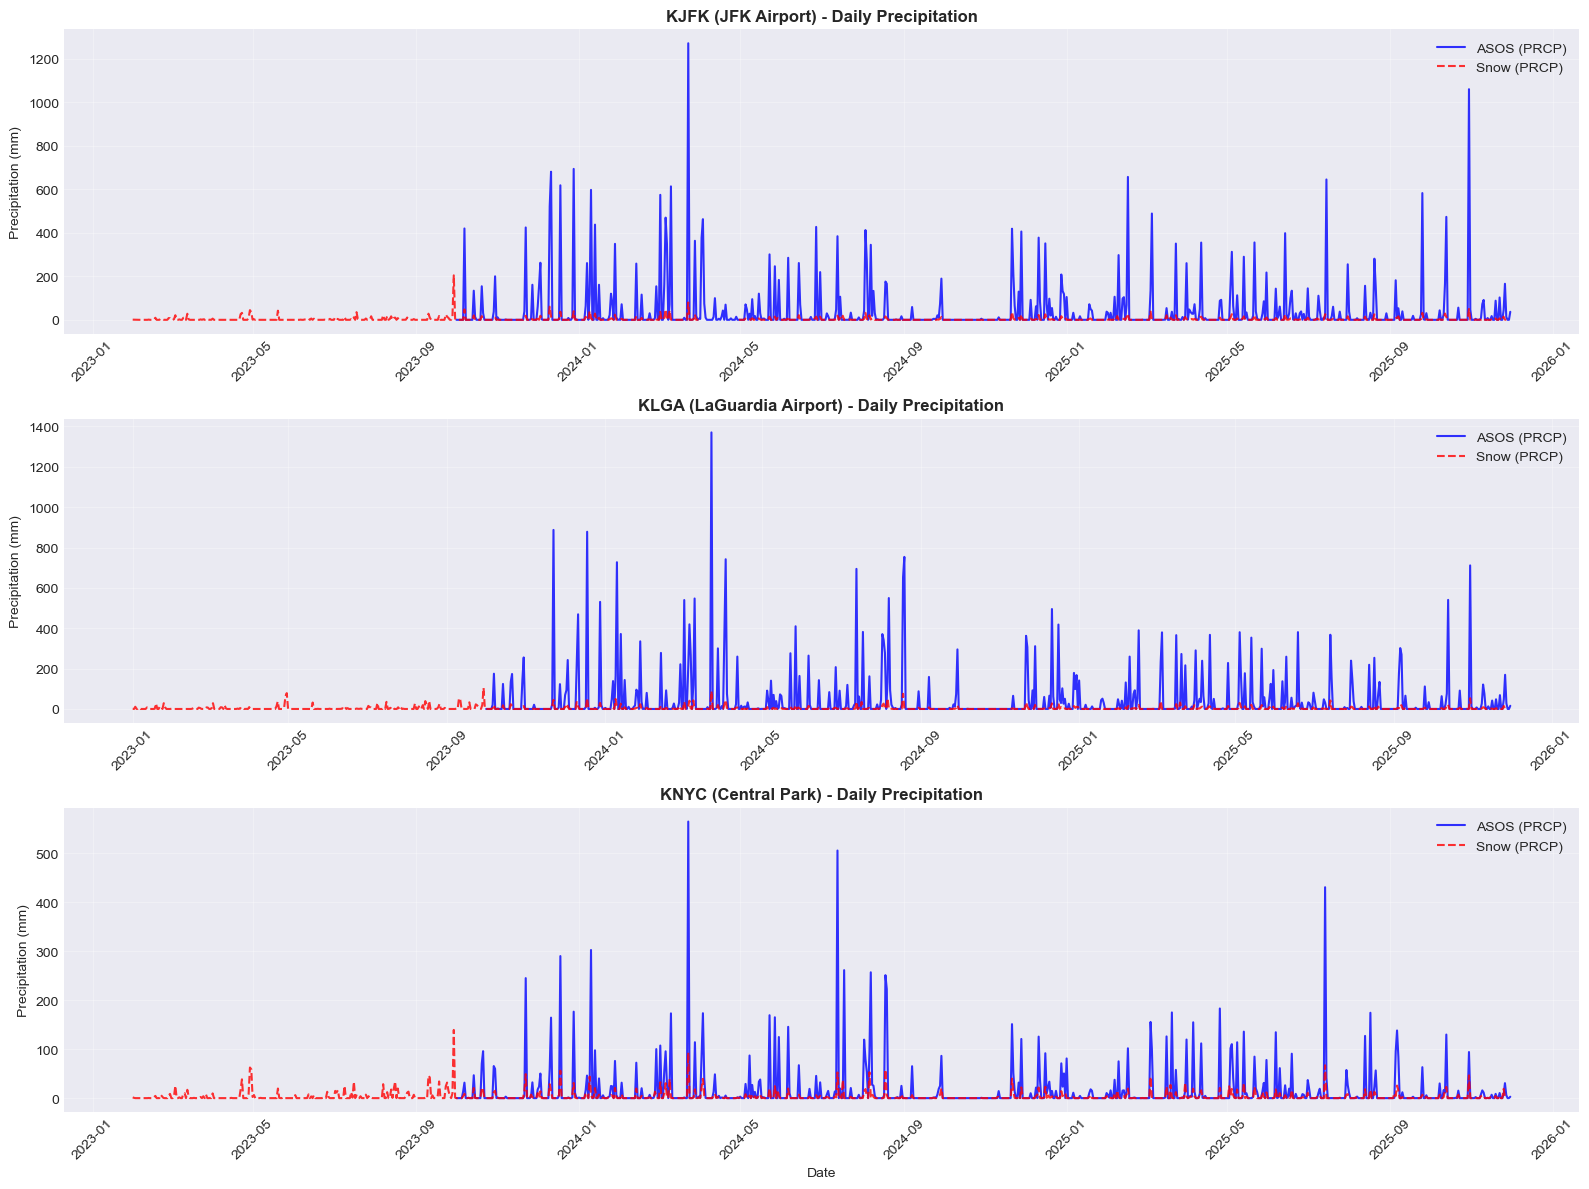

✓ Precipitation comparison plot created


In [ ]:
# Plot precipitation comparison
if 'df_asos_dict' in locals() and 'df_snow_dict' in locals():
    # Check which key exists for precipitation in ASOS data
    asos_prcp_key = 'PRCP' if 'PRCP' in df_asos_dict else 'precip_mm_sum'
    
    if asos_prcp_key in df_asos_dict and 'PRCP' in df_snow_dict:
        fig, axes = plt.subplots(3, 1, figsize=(16, 12))
        stations = ['KJFK', 'KLGA', 'KNYC']
        
        for idx, station in enumerate(stations):
            ax = axes[idx]
            
            # ASOS data
            if station in df_asos_dict[asos_prcp_key].columns:
                asos_dates = df_asos_dict[asos_prcp_key]['DATE']
                asos_values = df_asos_dict[asos_prcp_key][station]
                ax.plot(asos_dates, asos_values, label=f'ASOS ({asos_prcp_key})', 
                       linewidth=1.5, alpha=0.8, color='blue')
            
            # Snow data
            if station in df_snow_dict['PRCP'].columns:
                snow_dates = df_snow_dict['PRCP']['DATE']
                snow_values = df_snow_dict['PRCP'][station]
                ax.plot(snow_dates, snow_values, label='Snow (PRCP)', 
                       linewidth=1.5, alpha=0.8, color='red', linestyle='--')
            
            ax.set_title(f'{station} ({STATION_CODES.get(station, station)}) - Daily Precipitation', 
                        fontsize=12, fontweight='bold')
            ax.set_ylabel('Precipitation (mm)', fontsize=10)
            ax.legend(loc='upper right')
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='x', rotation=45)
        
        axes[-1].set_xlabel('Date', fontsize=10)
        plt.tight_layout()
        plt.show()
        
        print("✓ Precipitation comparison plot created")
    else:
        print("⚠ Precipitation data not available for comparison")
else:
    print("⚠ ASOS data dictionary not available")


### 12.2. Plot Temperature Comparison (ASOS vs Snow)


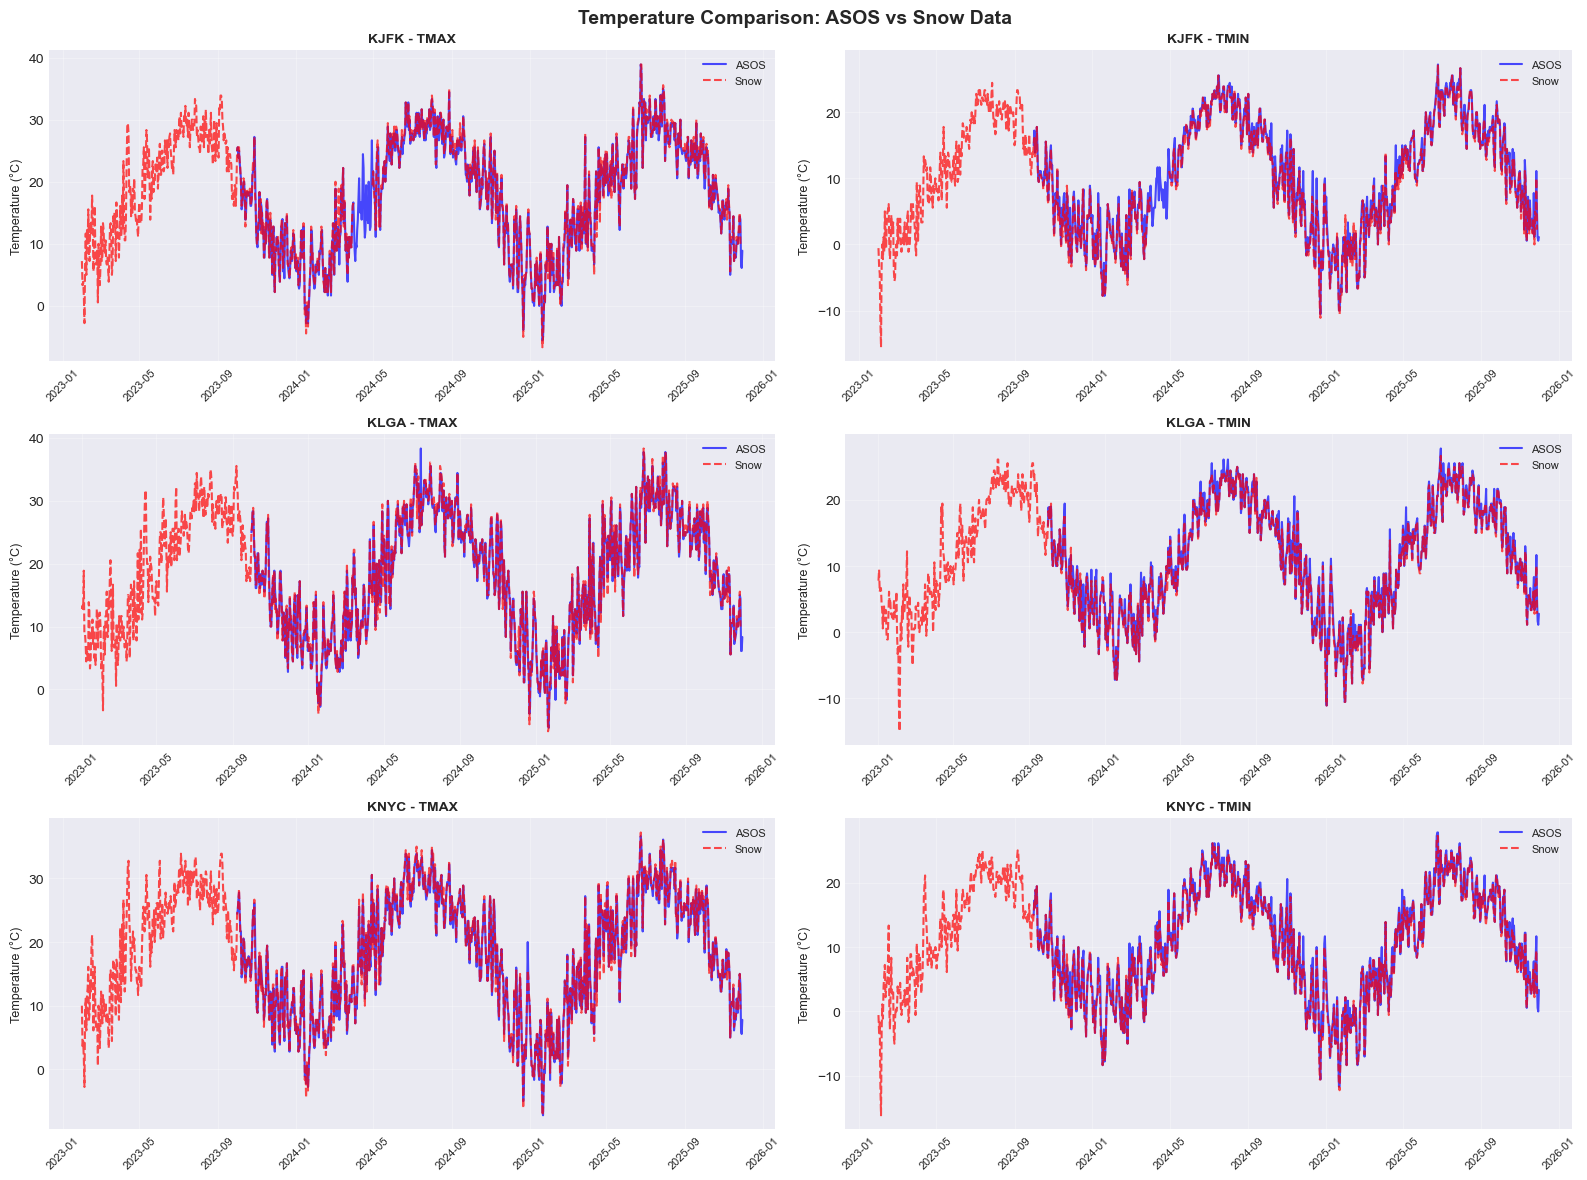

✓ Temperature comparison plot created


In [ ]:
# Plot temperature comparison (TMAX, TMIN, TAVG)
if 'df_asos_dict' in locals() and 'TMAX' in df_asos_dict:
    if 'df_snow_dict' in locals() and 'TMAX' in df_snow_dict:
        # Convert ASOS temperatures from Celsius to match snow data format
        # Snow data has temperatures that need conversion - let's check units first
        
        fig, axes = plt.subplots(3, 2, figsize=(16, 12))
        stations = ['KJFK', 'KLGA', 'KNYC']
        temp_params = ['TMAX', 'TMIN']
        
        for param_idx, param in enumerate(temp_params):
            for station_idx, station in enumerate(stations):
                ax = axes[station_idx, param_idx]
                
                # ASOS data (already in Celsius)
                if station in df_asos_dict[param].columns:
                    asos_dates = df_asos_dict[param]['DATE']
                    asos_values = df_asos_dict[param][station]
                    ax.plot(asos_dates, asos_values, label='ASOS', 
                           linewidth=1.5, alpha=0.7, color='blue')
                
                # Snow data (needs conversion from Fahrenheit to Celsius if needed)
                if param in df_snow_dict and station in df_snow_dict[param].columns:
                    snow_dates = df_snow_dict[param]['DATE']
                    snow_values = df_snow_dict[param][station]
                    # Snow data appears to be in Fahrenheit, convert to Celsius
                    # Check if values are > 50 (likely Fahrenheit), convert if needed
                    if snow_values.notna().any() and snow_values.max() > 50:
                        snow_values_c = (snow_values - 32) * 5/9
                    else:
                        snow_values_c = snow_values
                    ax.plot(snow_dates, snow_values_c, label='Snow', 
                           linewidth=1.5, alpha=0.7, color='red', linestyle='--')
                
                ax.set_title(f'{station} - {param}', fontsize=10, fontweight='bold')
                ax.set_ylabel('Temperature (°C)', fontsize=9)
                ax.legend(loc='best', fontsize=8)
                ax.grid(True, alpha=0.3)
                ax.tick_params(axis='x', rotation=45, labelsize=8)
        
        plt.suptitle('Temperature Comparison: ASOS vs Snow Data', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        print("✓ Temperature comparison plot created")
    else:
        print("⚠ Snow temperature data not available")
else:
    print("⚠ ASOS temperature data not available")


### 12.3. Plot All Parameters Summary (ASOS only)


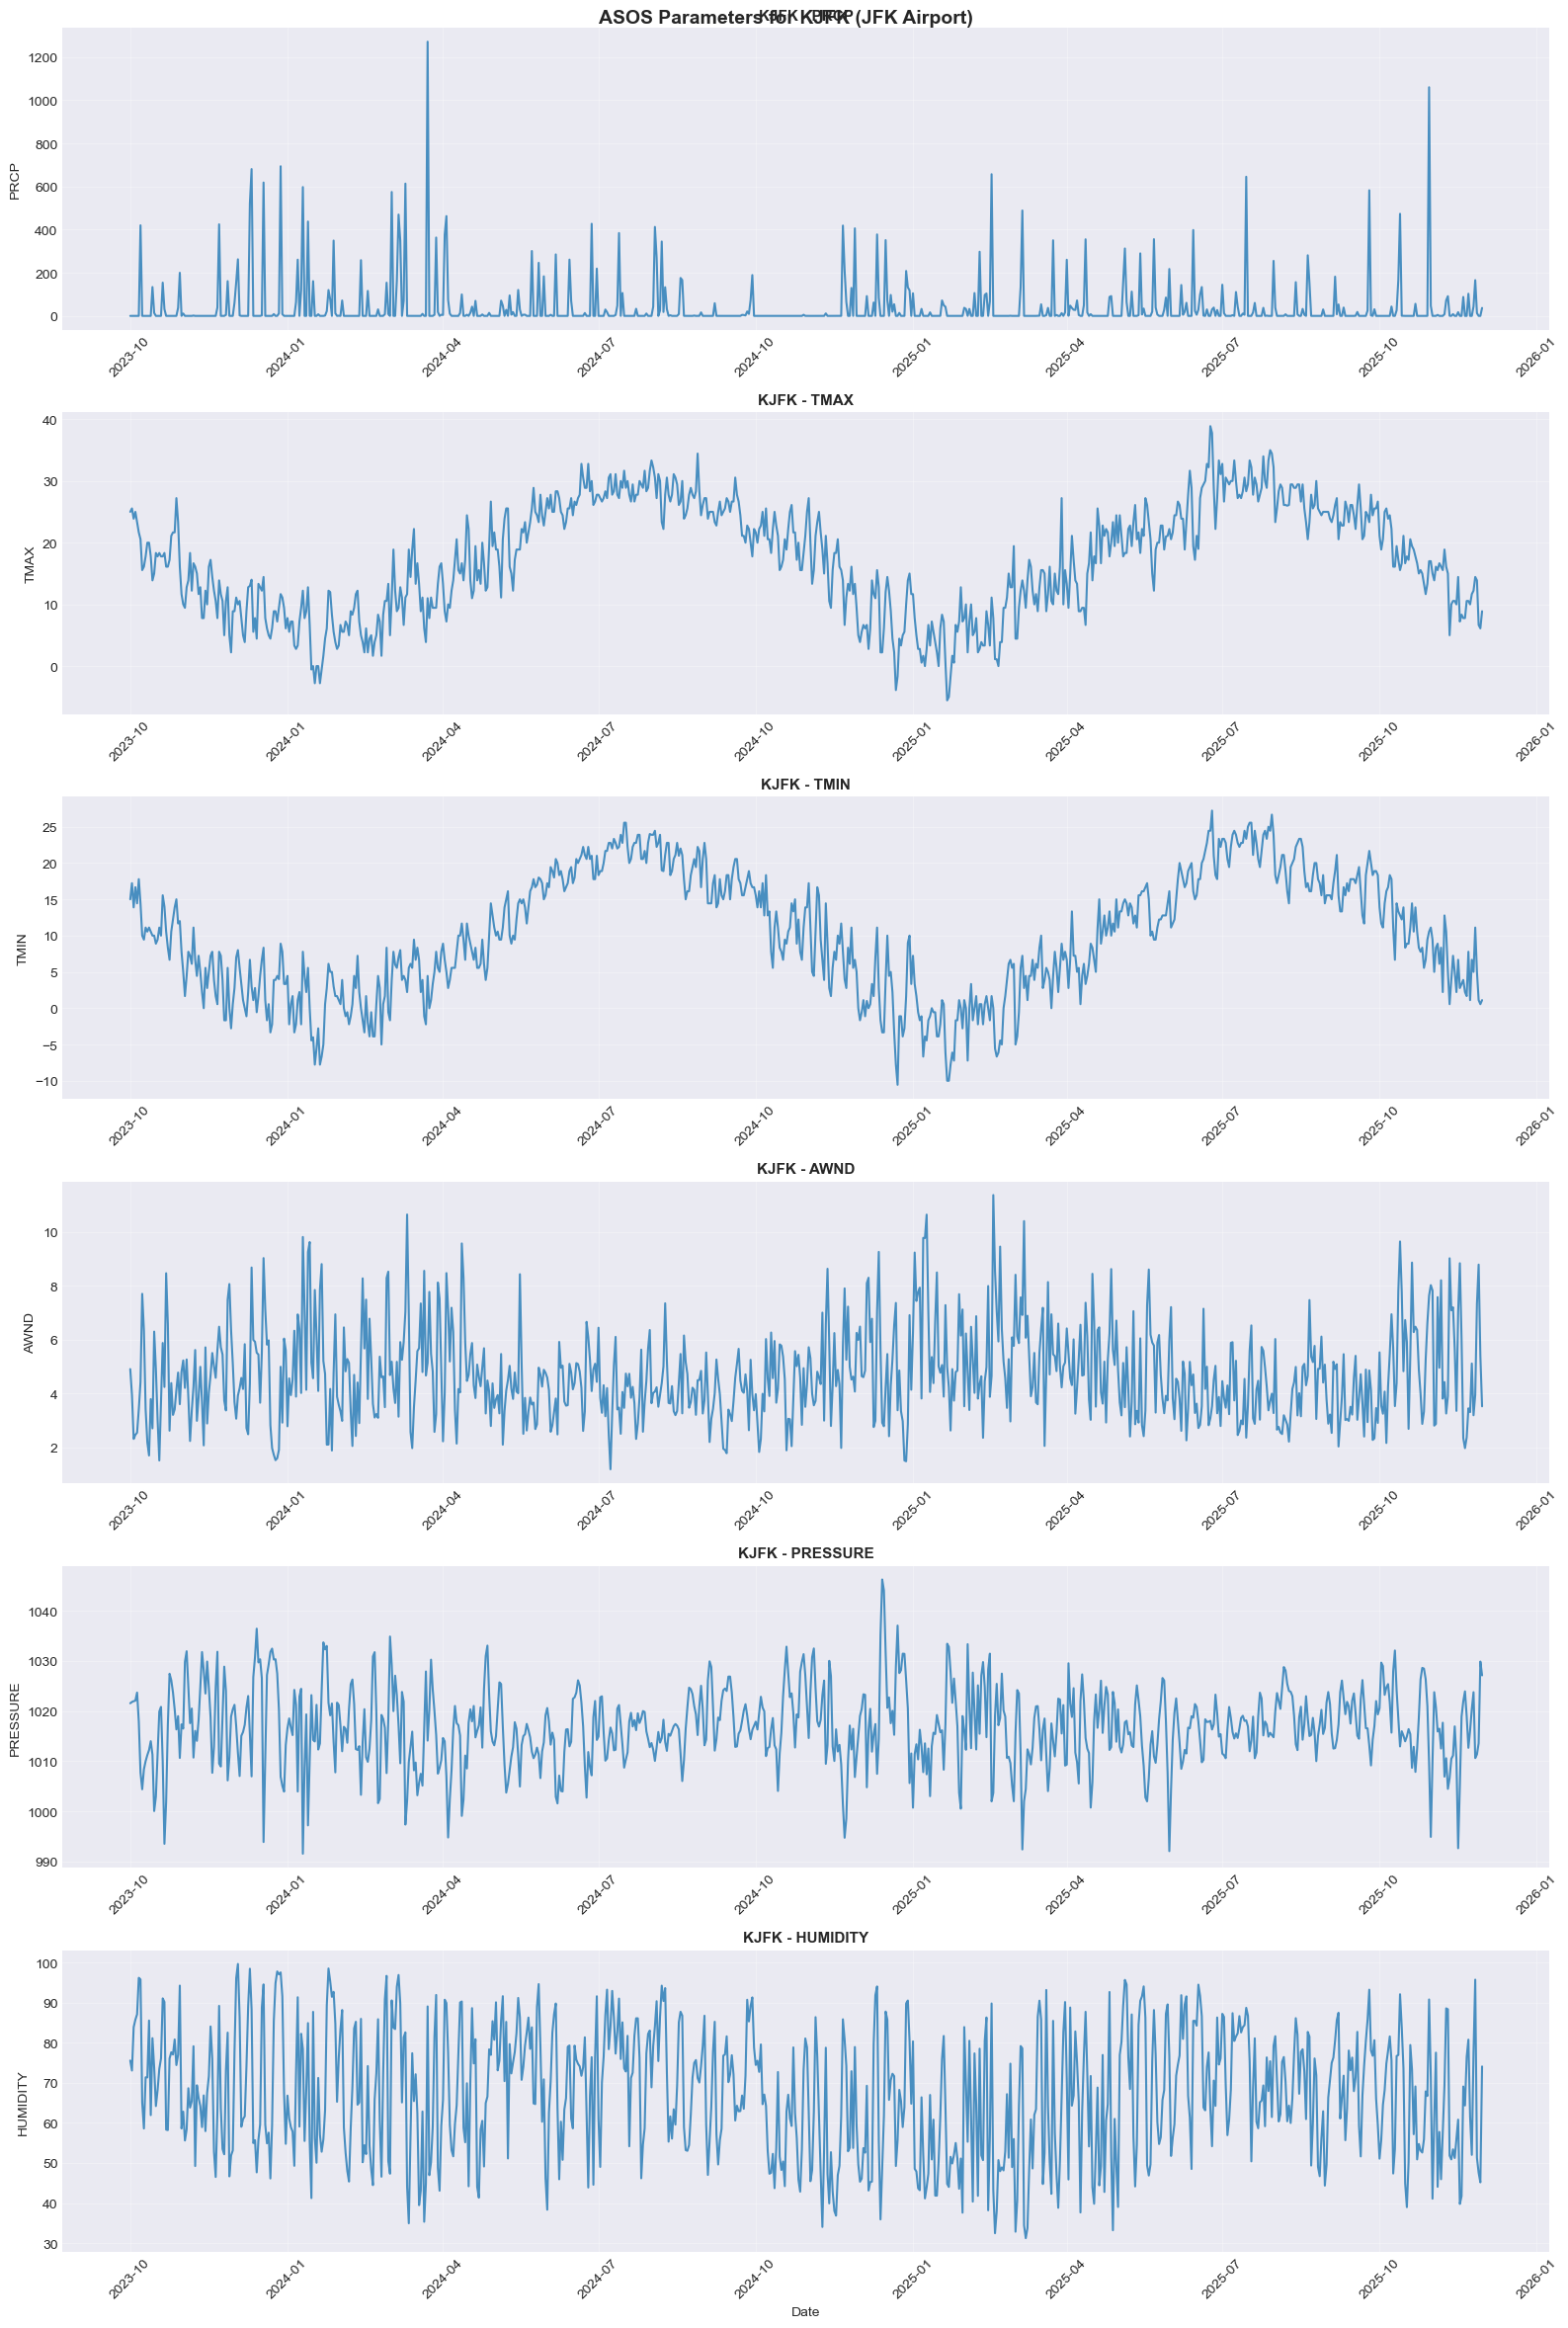

✓ Parameter summary plot created for KJFK


In [ ]:
# Plot all ASOS parameters for one station as example
if 'df_asos_dict' in locals() and len(df_asos_dict) > 0:
    station = 'KJFK'  # Example station
    
    # Select key parameters to plot (use PRCP if available, otherwise precip_mm_sum)
    prcp_key = 'PRCP' if 'PRCP' in df_asos_dict else 'precip_mm_sum'
    key_params = [prcp_key, 'TMAX', 'TMIN', 'AWND', 'PRESSURE', 'HUMIDITY']
    available_params = [p for p in key_params if p in df_asos_dict]
    
    if len(available_params) > 0:
        n_params = len(available_params)
        fig, axes = plt.subplots(n_params, 1, figsize=(16, 4*n_params))
        
        if n_params == 1:
            axes = [axes]
        
        for idx, param in enumerate(available_params):
            ax = axes[idx]
            
            if station in df_asos_dict[param].columns:
                dates = df_asos_dict[param]['DATE']
                values = df_asos_dict[param][station]
                ax.plot(dates, values, linewidth=1.5, alpha=0.8)
                ax.set_title(f'{station} - {param}', fontsize=11, fontweight='bold')
                ax.set_ylabel(param, fontsize=10)
                ax.grid(True, alpha=0.3)
                ax.tick_params(axis='x', rotation=45)
        
        axes[-1].set_xlabel('Date', fontsize=10)
        plt.suptitle(f'ASOS Parameters for {station} ({STATION_CODES.get(station, station)})', 
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        print(f"✓ Parameter summary plot created for {station}")
    else:
        print("⚠ No key parameters available to plot")
else:
    print("⚠ ASOS data dictionary not available")


### 12.4. Compare 5-minute ASOS vs Daily Snow Data on Rainy Days

Compare total precipitation from 5-minute ASOS data (aggregated) vs daily Snow data for rainy days to examine differences between data sources and resolutions.


In [ ]:
def compare_asos_5min_vs_snow_daily_rainy_days(asos_5min_data, df_snow_daily, station_id, start_date=None, end_date=None):
    """
    Compare total precipitation from 5-minute ASOS data vs daily Snow data for rainy days.
    
    Parameters:
    -----------
    asos_5min_data : dict
        Dictionary of 5-minute ASOS data by station
    df_snow_daily : pd.DataFrame
        Daily snow data
    station_id : str
        Station code (e.g., 'KJFK')
    start_date : str or datetime, optional
        Start date for period (default: None = all data)
    end_date : str or datetime, optional
        End date for period (default: None = all data)
        
    Returns:
    --------
    pd.DataFrame
        Comparison dataframe with rainy days and totals
    """
    if station_id not in asos_5min_data:
        print(f"⚠ Station {station_id} not found in ASOS 5-minute data")
        return None
    
    df_asos_5min = asos_5min_data[station_id].copy()
    
    # Filter snow data for this station
    snow_station = df_snow_daily[df_snow_daily['station_code'] == station_id].copy()
    
    if len(snow_station) == 0:
        print(f"⚠ Station {station_id} not found in snow data")
        return None
    
    # Filter by date range if provided
    if start_date:
        start_date = pd.to_datetime(start_date)
        df_asos_5min = df_asos_5min[df_asos_5min['datetime'] >= start_date]
        snow_station = snow_station[snow_station['DATE'] >= start_date]
    
    if end_date:
        end_date = pd.to_datetime(end_date)
        df_asos_5min = df_asos_5min[df_asos_5min['datetime'] <= end_date]
        snow_station = snow_station[snow_station['DATE'] <= end_date]
    
    # Create DATE column for ASOS data
    df_asos_5min['DATE'] = pd.to_datetime(df_asos_5min['datetime']).dt.date
    df_asos_5min['DATE'] = pd.to_datetime(df_asos_5min['DATE'])
    
    # Filter to rainy days in snow data
    if 'PRCP' in snow_station.columns:
        rainy_snow = snow_station[snow_station['PRCP'] > 0].copy()
    else:
        print(f"⚠ PRCP column not found in snow data")
        return None
    
    if len(rainy_snow) == 0:
        print(f"⚠ No rainy days found in snow data for {station_id}")
        return None
    
    # Get dates with rain from snow data
    rainy_dates = pd.to_datetime(rainy_snow['DATE']).dt.date
    
    # Calculate totals for each rainy day
    comparison_data = []
    
    for rain_date in rainy_dates:
        rain_date_dt = pd.to_datetime(rain_date)
        
        # ASOS 5-minute data for this day
        asos_day = df_asos_5min[df_asos_5min['DATE'].dt.date == rain_date]
        
        # Calculate total from 5-minute data
        if 'precip_mm' in asos_day.columns:
            asos_total = asos_day['precip_mm'].sum()
        else:
            asos_total = np.nan
        
        # Snow daily data for this day
        snow_day = rainy_snow[rainy_snow['DATE'].dt.date == rain_date]
        
        # Get snow total
        if len(snow_day) > 0:
            snow_total = snow_day['PRCP'].iloc[0]  # Should be one value per day
        else:
            snow_total = np.nan
        
        comparison_data.append({
            'DATE': rain_date_dt,
            'ASOS_5min_total': asos_total,
            'Snow_daily_total': snow_total,
            'Difference': asos_total - snow_total if not (pd.isna(asos_total) or pd.isna(snow_total)) else np.nan
        })
    
    df_comparison = pd.DataFrame(comparison_data)
    df_comparison = df_comparison.sort_values('DATE').reset_index(drop=True)
    
    return df_comparison

print("✓ Function defined: compare_asos_5min_vs_snow_daily_rainy_days")


✓ Function defined: compare_asos_5min_vs_snow_daily_rainy_days


In [ ]:
# Compare ASOS 5-minute vs Snow daily data for rainy days
print("="*60)
print("COMPARING ASOS 5-MINUTE VS SNOW DAILY DATA - RAINY DAYS")
print("="*60)

# Optional: Set date range (leave as None for all data)
# Example: start_date = '2024-01-01', end_date = '2024-03-31'
START_PERIOD = None  # or '2024-01-01'
END_PERIOD = None    # or '2024-03-31'

comparisons = {}
for station_id in STATION_CODES.keys():
    print(f"\n{station_id}:")
    comparison = compare_asos_5min_vs_snow_daily_rainy_days(
        asos_5min_data, 
        df_snow_daily, 
        station_id,
        start_date=START_PERIOD,
        end_date=END_PERIOD
    )
    
    if comparison is not None and len(comparison) > 0:
        comparisons[station_id] = comparison
        print(f"  Found {len(comparison)} rainy days for comparison")
        print(f"  ASOS 5-min total (sum): {comparison['ASOS_5min_total'].sum():.2f} mm")
        print(f"  Snow daily total (sum): {comparison['Snow_daily_total'].sum():.2f} mm")
        print(f"  Mean difference: {comparison['Difference'].mean():.2f} mm")

print(f"\n✓ Comparisons completed for {len(comparisons)} stations")


COMPARING ASOS 5-MINUTE VS SNOW DAILY DATA - RAINY DAYS

KNYC:
  Found 343 rainy days for comparison
  ASOS 5-min total (sum): 12099.90 mm
  Snow daily total (sum): 3490.47 mm
  Mean difference: 25.10 mm

KJFK:
  Found 344 rainy days for comparison
  ASOS 5-min total (sum): 30807.51 mm
  Snow daily total (sum): 2983.23 mm
  Mean difference: 80.88 mm

KLGA:
  Found 352 rainy days for comparison
  ASOS 5-min total (sum): 34013.06 mm
  Snow daily total (sum): 3511.55 mm
  Mean difference: 86.65 mm

✓ Comparisons completed for 3 stations


## 13. Plot Data for a Specific Period

Function to plot data for a specified date range


In [ ]:
def plot_period_data(df_asos_dict, df_snow_dict, parameter, start_date, end_date, 
                     stations=None, figsize=(16, 6), title_suffix=""):
    """
    Plot parameter data for a specific date period, comparing ASOS and Snow data.
    
    Parameters:
    -----------
    df_asos_dict : dict
        Dictionary of ASOS data organized by parameter
    df_snow_dict : dict
        Dictionary of Snow data organized by parameter
    parameter : str
        Parameter to plot (e.g., 'PRCP', 'TMAX', 'TMIN', 'TAVG')
    start_date : str or datetime
        Start date (e.g., '2024-01-01')
    end_date : str or datetime
        End date (e.g., '2024-03-31')
    stations : list, optional
        List of station codes to plot (e.g., ['KJFK', 'KLGA', 'KNYC'])
        If None, plots all available stations
    figsize : tuple, optional
        Figure size (width, height)
    title_suffix : str, optional
        Additional text to append to title
        
    Returns:
    --------
    fig, axes : matplotlib figure and axes objects
    """
    # Convert dates
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)
    
    # Get parameter data
    asos_key = parameter if parameter in df_asos_dict else None
    snow_key = parameter if parameter in df_snow_dict else None
    
    if asos_key is None and snow_key is None:
        print(f"⚠ Parameter '{parameter}' not found in either ASOS or Snow data")
        return None, None
    
    # Determine stations to plot
    if stations is None:
        stations = []
        if asos_key and len(df_asos_dict[asos_key]) > 0:
            stations.extend([c for c in df_asos_dict[asos_key].columns if c != 'DATE'])
        if snow_key and len(df_snow_dict[snow_key]) > 0:
            stations.extend([c for c in df_snow_dict[snow_key].columns if c != 'DATE'])
        stations = sorted(list(set(stations)))
    
    if len(stations) == 0:
        print("⚠ No stations found to plot")
        return None, None
    
    # Create figure
    fig, axes = plt.subplots(len(stations), 1, figsize=figsize)
    if len(stations) == 1:
        axes = [axes]
    
    # Plot each station
    for idx, station in enumerate(stations):
        ax = axes[idx]
        
        # ASOS data
        if asos_key and station in df_asos_dict[asos_key].columns:
            df_asos = df_asos_dict[asos_key].copy()
            df_asos['DATE'] = pd.to_datetime(df_asos['DATE'])
            df_asos_period = df_asos[(df_asos['DATE'] >= start_date) & (df_asos['DATE'] <= end_date)]
            
            if len(df_asos_period) > 0:
                ax.plot(df_asos_period['DATE'], df_asos_period[station], 
                       label='ASOS', linewidth=2, alpha=0.8, color='blue', marker='o', markersize=3)
        
        # Snow data
        if snow_key and station in df_snow_dict[snow_key].columns:
            df_snow = df_snow_dict[snow_key].copy()
            df_snow['DATE'] = pd.to_datetime(df_snow['DATE'])
            df_snow_period = df_snow[(df_snow['DATE'] >= start_date) & (df_snow['DATE'] <= end_date)]
            
            if len(df_snow_period) > 0:
                # Convert temperature if needed (check if values are in Fahrenheit)
                values = df_snow_period[station].copy()
                if parameter in ['TMAX', 'TMIN', 'TAVG'] and values.notna().any():
                    if values.max() > 50:  # Likely Fahrenheit
                        values = (values - 32) * 5/9
                
                ax.plot(df_snow_period['DATE'], values,
                       label='Snow', linewidth=2, alpha=0.8, color='red', 
                       marker='s', markersize=3, linestyle='--')
        
        # Formatting
        station_name = STATION_CODES.get(station, station)
        ax.set_title(f'{station} ({station_name}) - {parameter}', 
                    fontsize=12, fontweight='bold')
        ax.set_ylabel(f'{parameter}', fontsize=10)
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        
        # Format x-axis dates
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=max(1, (end_date - start_date).days // 10)))
    
    axes[-1].set_xlabel('Date', fontsize=10)
    
    # Overall title
    period_str = f"{start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}"
    fig.suptitle(f'{parameter} Comparison: ASOS vs Snow Data\\n{period_str}{title_suffix}', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    return fig, axes

print("✓ Function defined: plot_period_data")


✓ Function defined: plot_period_data


### 13.1. Example: Plot Precipitation for a Period


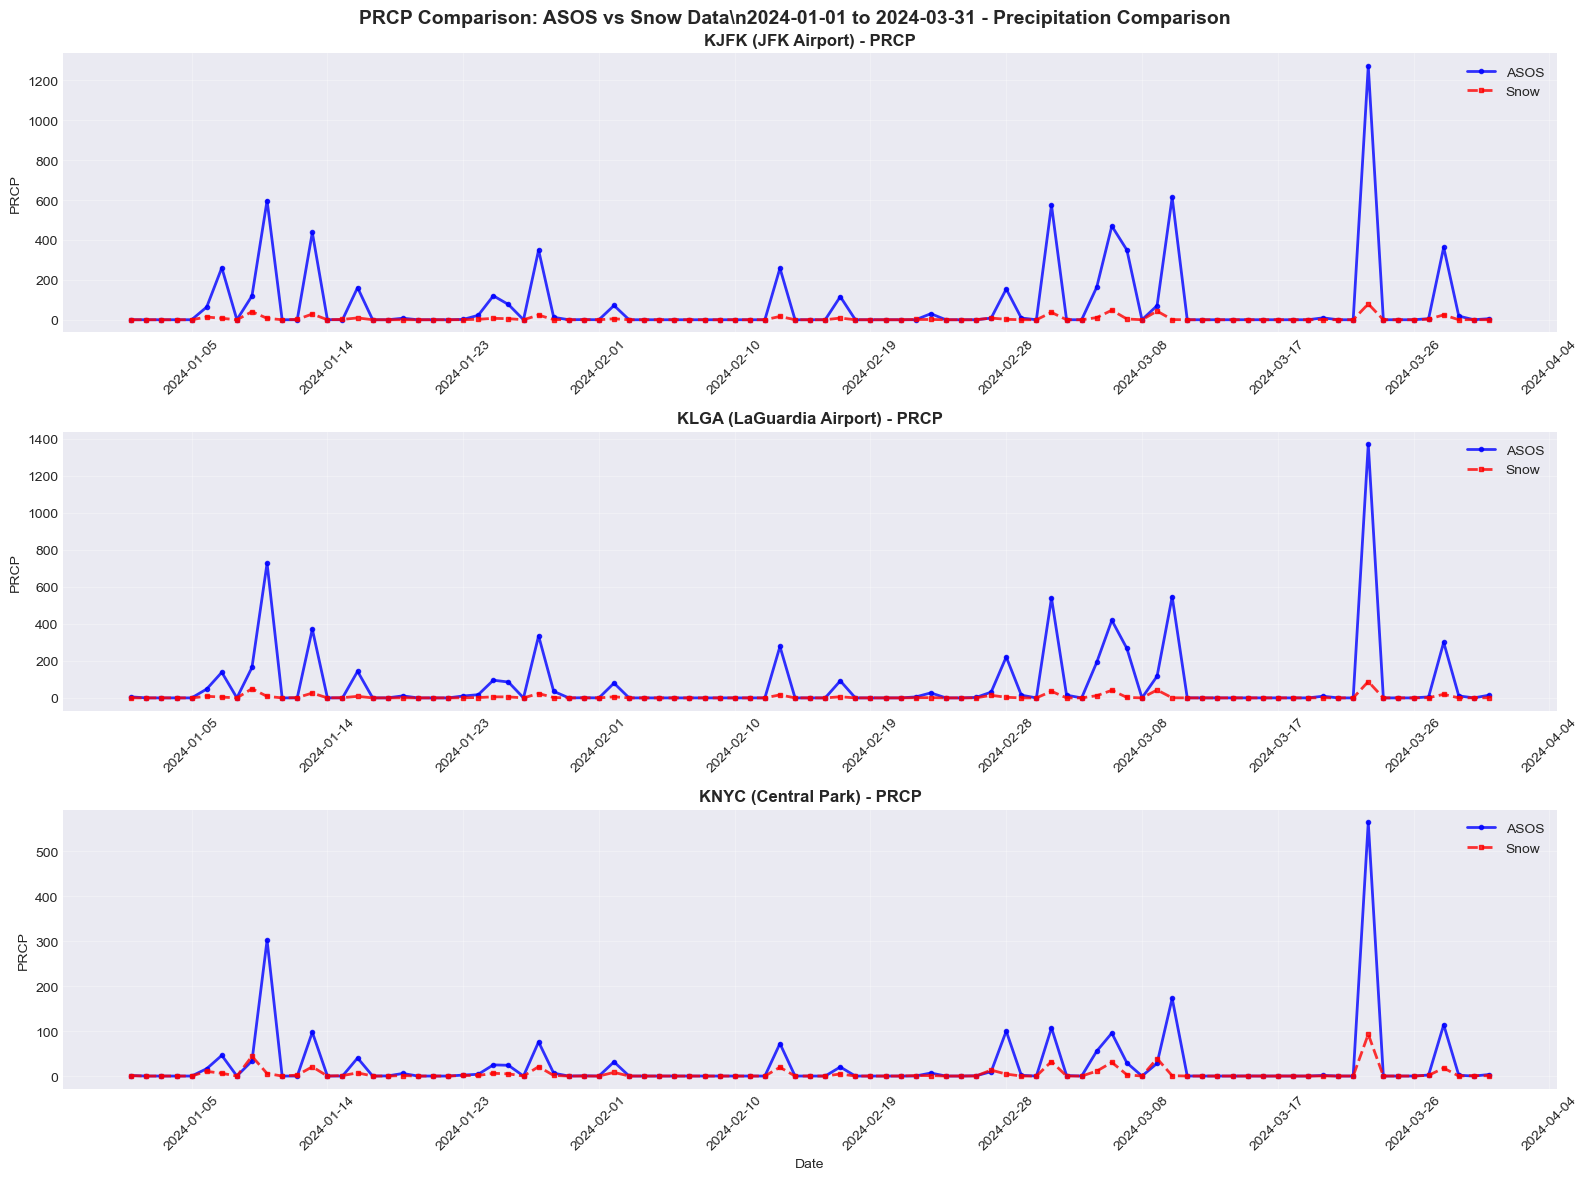

✓ Plot created


In [ ]:
# Example: Plot precipitation for a specific period
# Modify these dates to plot your desired period
START_DATE = '2024-01-01'
END_DATE = '2024-03-31'

# Check which key exists for precipitation
asos_prcp_key = 'PRCP' if 'PRCP' in df_asos_dict else 'precip_mm_sum'

if asos_prcp_key in df_asos_dict and 'PRCP' in df_snow_dict:
    fig, axes = plot_period_data(
        df_asos_dict, 
        df_snow_dict, 
        parameter=asos_prcp_key,  # Use the actual key name
        start_date=START_DATE,
        end_date=END_DATE,
        stations=None,  # None = plot all stations
        figsize=(16, 12),
        title_suffix=" - Precipitation Comparison"
    )
    
    if fig is not None:
        plt.show()
        print("✓ Plot created")
else:
    print("⚠ Precipitation data not available for plotting")


### 13.2. Example: Plot Temperature for a Period


In [ ]:
# Example: Plot temperature for a specific period
# Modify these dates to plot your desired period
START_DATE_TEMP = '2024-01-01'
END_DATE_TEMP = '2024-03-31'
TEMPERATURE_PARAM = 'TMAX'  # Options: 'TMAX', 'TMIN', 'TAVG'

if TEMPERATURE_PARAM in df_asos_dict and TEMPERATURE_PARAM in df_snow_dict:
    fig, axes = plot_period_data(
        df_asos_dict, 
        df_snow_dict, 
        parameter=TEMPERATURE_PARAM,
        start_date=START_DATE_TEMP,
        end_date=END_DATE_TEMP,
        stations=None,  # None = plot all stations
        figsize=(16, 12),
        title_suffix=f" - {TEMPERATURE_PARAM} Comparison"
    )
    
    if fig is not None:
        plt.show()
        print("✓ Plot created")
else:
    print(f"⚠ {TEMPERATURE_PARAM} data not available for plotting")


### 13.3. Plot Any Parameter for Custom Period

Use the function below to plot any parameter for any date range:

```python
# Example usage:
fig, axes = plot_period_data(
    df_asos_dict, 
    df_snow_dict, 
    parameter='PRCP',  # or 'TMAX', 'TMIN', 'TAVG', 'AWND', etc.
    start_date='2024-01-15',
    end_date='2024-02-15',
    stations=['KJFK', 'KLGA'],  # or None for all stations
    figsize=(16, 8),
    title_suffix=" - Custom Period"
)
plt.show()
```


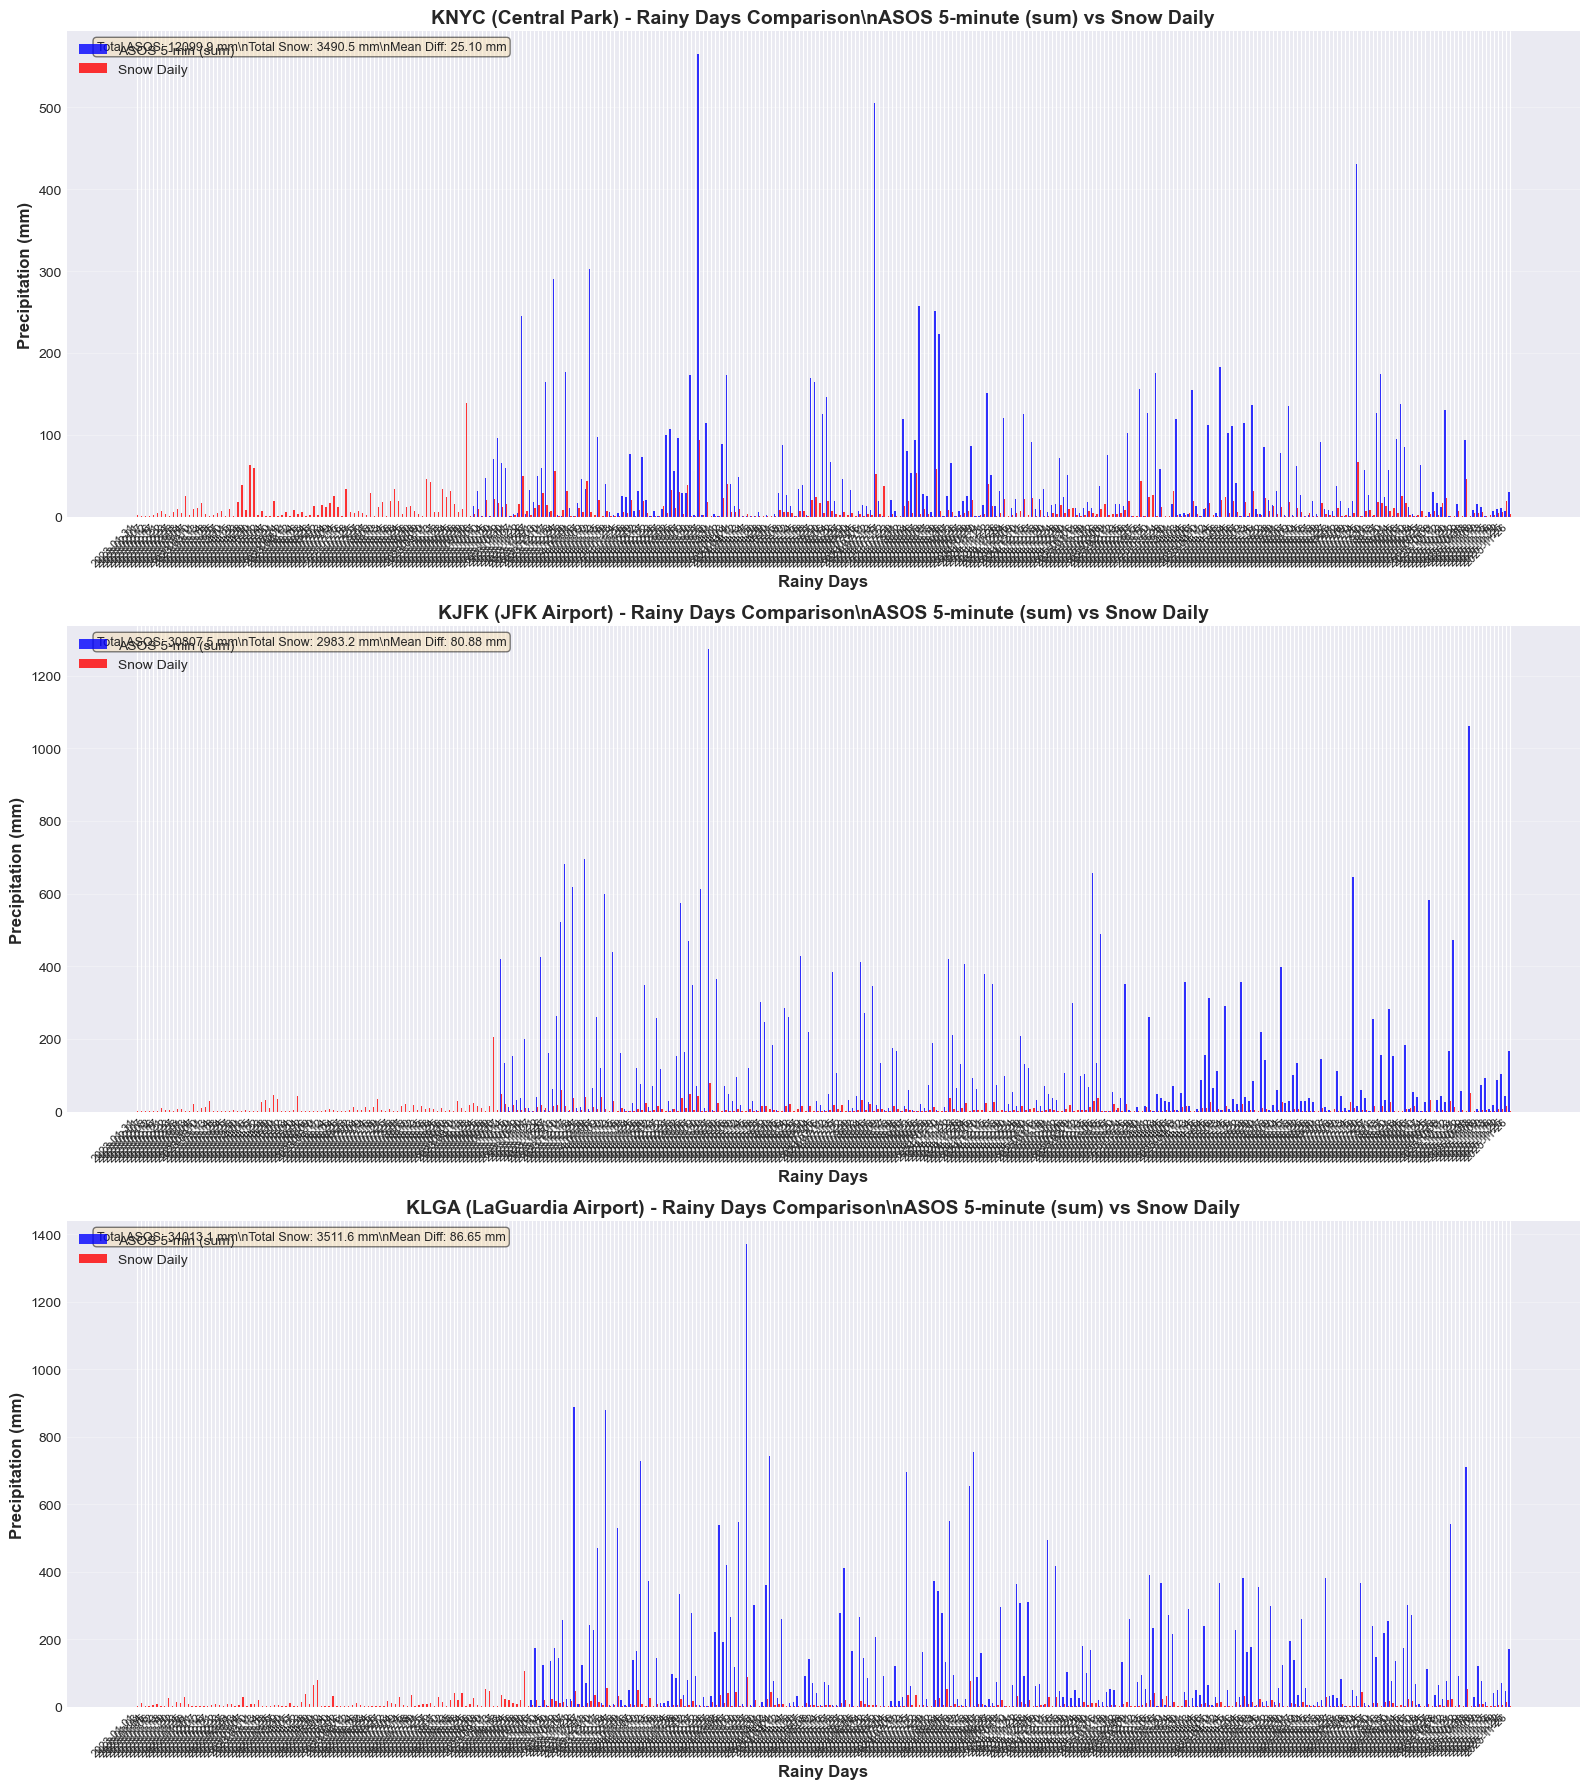

✓ Bar chart comparison created


In [ ]:
# Plot bar chart comparing totals for rainy days
if len(comparisons) > 0:
    # Option 1: Plot all rainy days for each station
    fig, axes = plt.subplots(len(comparisons), 1, figsize=(16, 6*len(comparisons)))
    
    if len(comparisons) == 1:
        axes = [axes]
    
    for idx, (station_id, df_comp) in enumerate(comparisons.items()):
        ax = axes[idx]
        
        # Prepare data for plotting
        dates = df_comp['DATE']
        asos_totals = df_comp['ASOS_5min_total']
        snow_totals = df_comp['Snow_daily_total']
        
        # Create bar plot
        x_pos = np.arange(len(dates))
        width = 0.35
        
        bars1 = ax.bar(x_pos - width/2, asos_totals, width, 
                      label='ASOS 5-min (sum)', color='blue', alpha=0.8)
        bars2 = ax.bar(x_pos + width/2, snow_totals, width, 
                      label='Snow Daily', color='red', alpha=0.8)
        
        # Formatting
        ax.set_xlabel('Rainy Days', fontsize=12, fontweight='bold')
        ax.set_ylabel('Precipitation (mm)', fontsize=12, fontweight='bold')
        ax.set_title(f'{station_id} ({STATION_CODES.get(station_id, station_id)}) - Rainy Days Comparison\\n' + 
                    f'ASOS 5-minute (sum) vs Snow Daily', 
                    fontsize=14, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels([d.strftime('%Y-%m-%d') for d in dates], 
                          rotation=45, ha='right', fontsize=8)
        ax.legend(loc='upper left', fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add summary text
        summary_text = f'Total ASOS: {asos_totals.sum():.1f} mm\\n'
        summary_text += f'Total Snow: {snow_totals.sum():.1f} mm\\n'
        diff_mean = df_comp['Difference'].mean()
        summary_text += f'Mean Diff: {diff_mean:.2f} mm'
        ax.text(0.02, 0.98, summary_text, transform=ax.transAxes,
               verticalalignment='top', fontsize=9,
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Bar chart comparison created")
else:
    print("⚠ No comparison data available for plotting")


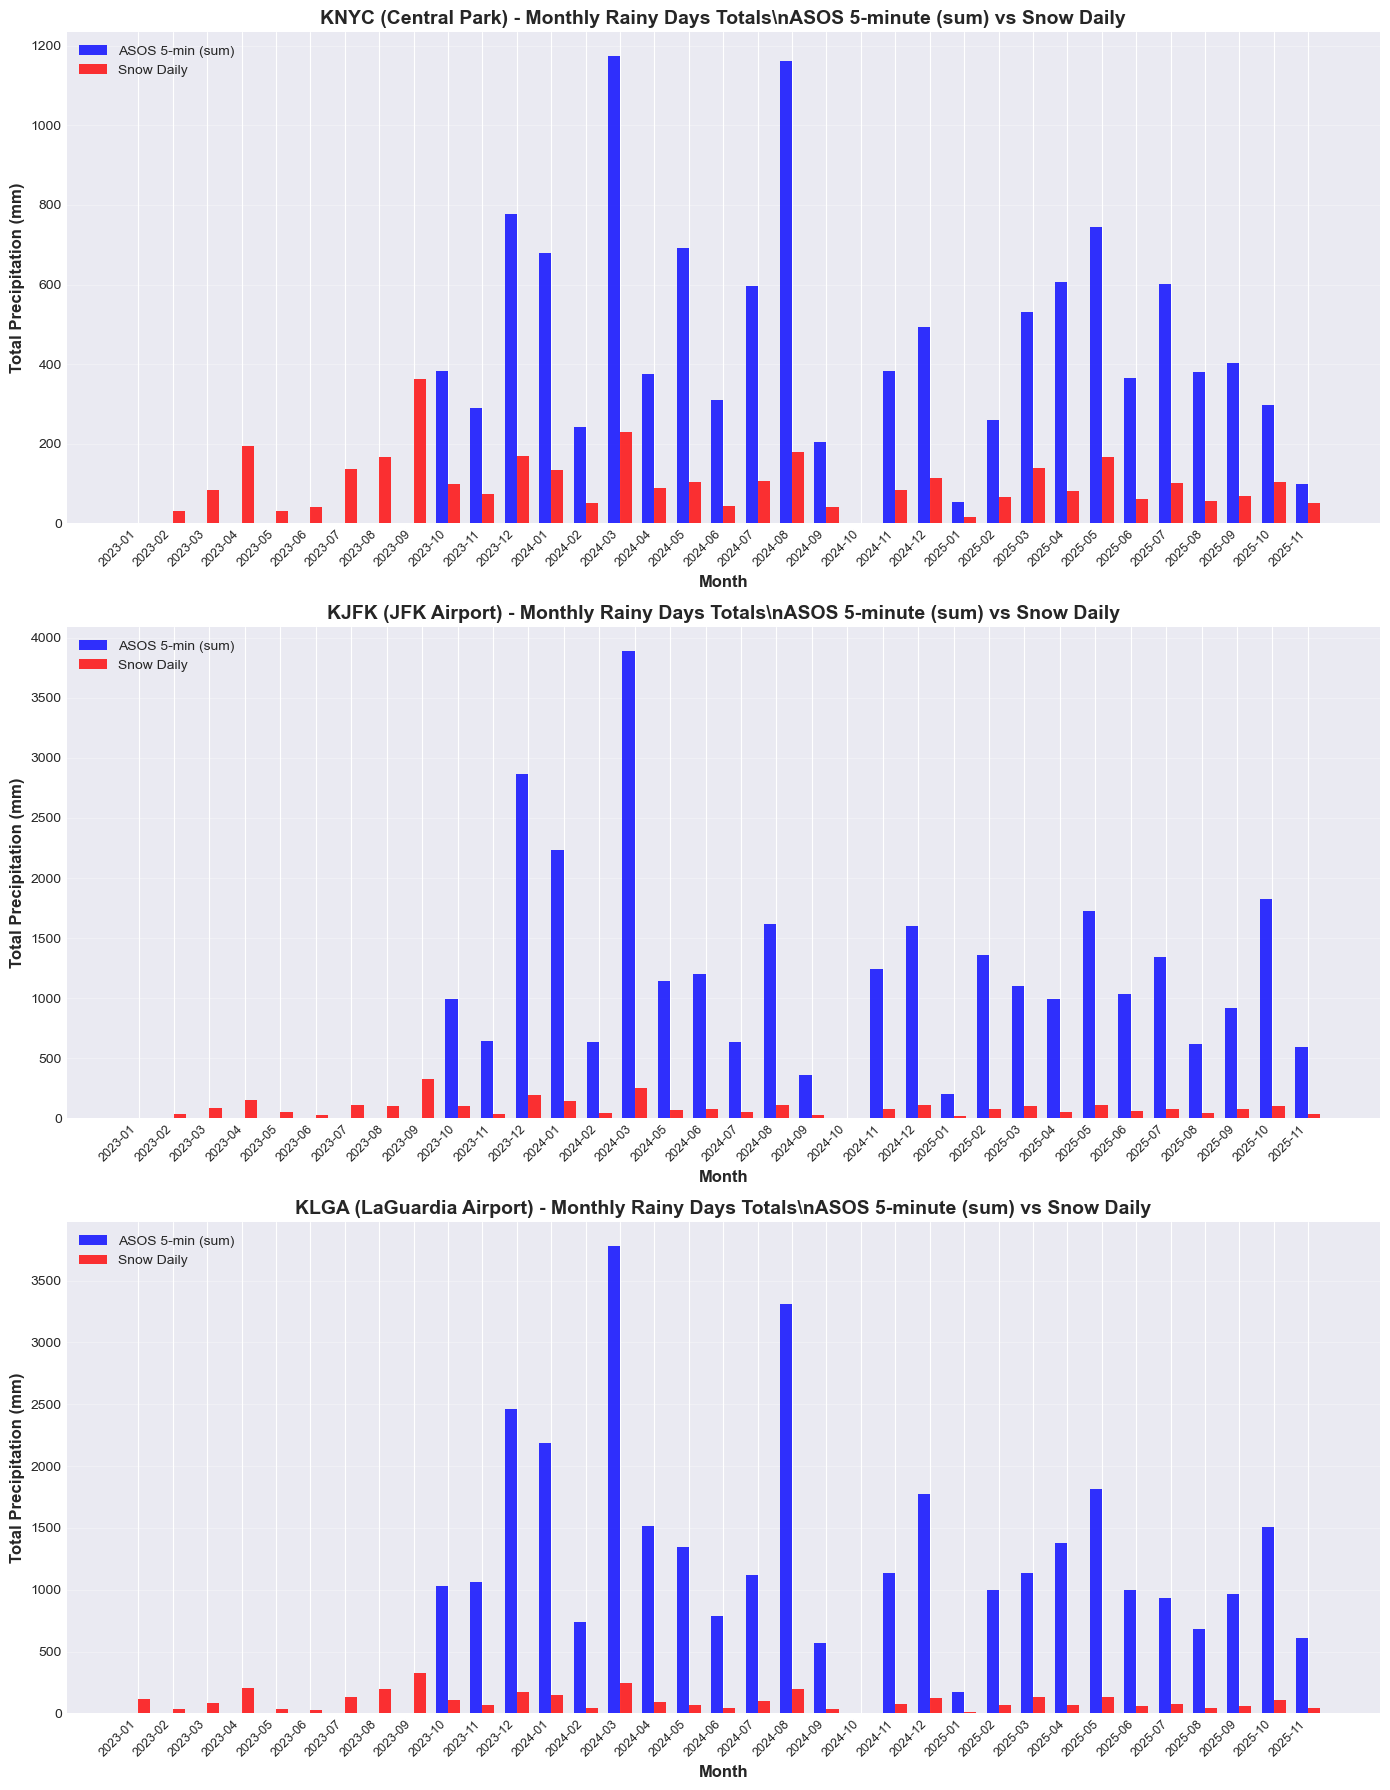

✓ Monthly aggregated comparison created


In [ ]:
# Alternative: Plot aggregated totals by month or period
if len(comparisons) > 0:
    fig, axes = plt.subplots(len(comparisons), 1, figsize=(14, 6*len(comparisons)))
    
    if len(comparisons) == 1:
        axes = [axes]
    
    for idx, (station_id, df_comp) in enumerate(comparisons.items()):
        ax = axes[idx]
        
        # Aggregate by month
        df_comp['YearMonth'] = df_comp['DATE'].dt.to_period('M')
        monthly = df_comp.groupby('YearMonth').agg({
            'ASOS_5min_total': 'sum',
            'Snow_daily_total': 'sum'
        }).reset_index()
        
        monthly['YearMonth_str'] = monthly['YearMonth'].astype(str)
        x_pos = np.arange(len(monthly))
        width = 0.35
        
        bars1 = ax.bar(x_pos - width/2, monthly['ASOS_5min_total'], width,
                      label='ASOS 5-min (sum)', color='blue', alpha=0.8)
        bars2 = ax.bar(x_pos + width/2, monthly['Snow_daily_total'], width,
                      label='Snow Daily', color='red', alpha=0.8)
        
        ax.set_xlabel('Month', fontsize=12, fontweight='bold')
        ax.set_ylabel('Total Precipitation (mm)', fontsize=12, fontweight='bold')
        ax.set_title(f'{station_id} ({STATION_CODES.get(station_id, station_id)}) - Monthly Rainy Days Totals\\n' + 
                    f'ASOS 5-minute (sum) vs Snow Daily', 
                    fontsize=14, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(monthly['YearMonth_str'], rotation=45, ha='right', fontsize=9)
        ax.legend(loc='upper left', fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Monthly aggregated comparison created")


In [ ]:
# Summary statistics table
if len(comparisons) > 0:
    print("="*60)
    print("SUMMARY STATISTICS - ASOS 5-MIN vs SNOW DAILY")
    print("="*60)
    
    summary_list = []
    for station_id, df_comp in comparisons.items():
        summary_list.append({
            'Station': station_id,
            'Rainy Days': len(df_comp),
            'ASOS Total (mm)': df_comp['ASOS_5min_total'].sum(),
            'Snow Total (mm)': df_comp['Snow_daily_total'].sum(),
            'Difference (mm)': df_comp['Difference'].sum(),
            'Mean Diff (mm)': df_comp['Difference'].mean(),
            'RMSE (mm)': np.sqrt((df_comp['Difference']**2).mean()),
            'Correlation': df_comp['ASOS_5min_total'].corr(df_comp['Snow_daily_total'])
        })
    
    df_summary = pd.DataFrame(summary_list)
    print("\n" + df_summary.to_string(index=False))
    
    # Display comparison dataframes
    print("\n" + "="*60)
    print("DETAILED COMPARISON DATA")
    print("="*60)
    for station_id, df_comp in comparisons.items():
        print(f"\n{station_id} - First 10 rainy days:")
        print(df_comp.head(10)[['DATE', 'ASOS_5min_total', 'Snow_daily_total', 'Difference']].to_string(index=False))


SUMMARY STATISTICS - ASOS 5-MIN vs SNOW DAILY

Station  Rainy Days  ASOS Total (mm)  Snow Total (mm)  Difference (mm)  Mean Diff (mm)  RMSE (mm)  Correlation
   KNYC         343       12099.8996         3490.468        8609.4316       25.100384  67.492062     0.510804
   KJFK         344       30807.5076         2983.230       27824.2776       80.884528 178.820102     0.430132
   KLGA         352       34013.0638         3511.550       30501.5138       86.652028 186.548156     0.499334

DETAILED COMPARISON DATA

KNYC - First 10 rainy days:
      DATE  ASOS_5min_total  Snow_daily_total  Difference
2023-01-31              0.0             1.524      -1.524
2023-02-01              0.0             0.508      -0.508
2023-02-07              0.0             0.508      -0.508
2023-02-12              0.0             0.254      -0.254
2023-02-16              0.0             1.778      -1.778
2023-02-17              0.0             4.572      -4.572
2023-02-21              0.0             6.858   

## 11. Data Ready for Analysis

The data is now organized and ready:

- **`df_asos_dict`**: Dictionary of ASOS data organized by parameter
  - `df_asos_dict['PRCP']` - Precipitation data (DATE + station columns)
  - `df_asos_dict['TMAX']` - Max temperature data
  - `df_asos_dict['TMIN']` - Min temperature data
  - `df_asos_dict['TAVG']` - Average temperature data
  - etc.

- **`df_snow_dict`**: Dictionary of Snow data organized by parameter
  - Same structure as ASOS data
  - Can be compared parameter by parameter

**Next Steps:**
- Compare ASOS vs Snow data for each parameter
- Analyze trends and patterns
- Create visualizations
